In [32]:
import ijson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests

In [33]:

def validate_youtube_data_sample(json_file, chunk_size=10, max_records=100):
    """
    Efficiently processes the first few records of a large JSON file containing YouTube video data to check if the code works.
    Args:
        json_file (str): Path to the JSON file.
        chunk_size (int): Number of records to process per batch.
        max_records (int): Maximum number of records to process before stopping.

    Returns:
        pd.DataFrame: A DataFrame containing video validation results.
    """
    base_url = "https://www.youtube.com/watch?v="
    results = []
    record_counter = 0
    
    def is_video_valid(url):
        """
        Check if the YouTube video URL is valid by sending a GET request.
        Returns True if the URL is valid, False otherwise.
        """
        try:
            response = requests.get(url)
            # Check if status code is 200 (OK), meaning the video exists
            if response.status_code == 200:
                return True
            else:
                return False
        except requests.RequestException:
            return False
    
    with open(json_file, 'r') as file:
        parser = ijson.kvitems(file, '')  # Efficiently parse key-value pairs
        
        for video_id, details in parser:
            if not isinstance(details, dict):
                continue  # Skip invalid entries
            
            video_url = f"{base_url}{video_id}"
            is_valid = is_video_valid(video_url)
            
            results.append({
                "Video ID": video_id,
                "URL": video_url,
                "Valid": is_valid,  # Store whether the link is valid
                "Duration": details.get('duration', 0),
                "Sentences": details.get('sentences', []),
                "Path": details.get('path', '')
            })
            
            # Stop when we reach the max number of records (100 in this case)
            record_counter += 1
            if record_counter >= max_records:
                break
            
            # Process in chunks to avoid memory overload
            if len(results) >= chunk_size:
                print(f"Processed {record_counter} records...")
                yield pd.DataFrame(results)
                results = []  # Clear the batch
    
    # Yield any remaining records
    if results:
        yield pd.DataFrame(results)


In [34]:
def plot_duration_distribution(df):
    """Plots the distribution of video durations."""
    if "Duration" not in df.columns or df["Duration"].isna().all():
        print("No valid duration data to plot.")
        return
    
    plt.figure(figsize=(10, 5))
    plt.hist(df['Duration'].dropna(), bins=20, edgecolor='black')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Video Durations')
    plt.show()


In [35]:
json_path = r'C:\Users\yashM\Downloads\OneDrive_1_1-26-2025\video_chapters_tr_youtube.json'
all_dfs = []


In [36]:
# Process the first 100 records
for chunk in validate_youtube_data_sample(json_path, chunk_size=10, max_records=100):
    all_dfs.append(chunk)


Processed 10 records...
Processed 20 records...
Processed 30 records...
Processed 40 records...
Processed 50 records...
Processed 60 records...
Processed 70 records...
Processed 80 records...
Processed 90 records...


Index(['Video ID', 'URL', 'Valid', 'Duration', 'Sentences', 'Path'], dtype='object')
      Video ID                                          URL  Valid Duration  \
0  jOiOkFwBpNI  https://www.youtube.com/watch?v=jOiOkFwBpNI   True    189.0   
1  vBv5G5emgl0  https://www.youtube.com/watch?v=vBv5G5emgl0   True    433.0   
2  IkrXmYjWgIo  https://www.youtube.com/watch?v=IkrXmYjWgIo   True    988.0   
3  2rj9fXhUKnI  https://www.youtube.com/watch?v=2rj9fXhUKnI   True    771.0   
4  C0sdqnGCE2w  https://www.youtube.com/watch?v=C0sdqnGCE2w   True    955.0   

                                           Sentences                 Path  
0  [You won’t look amazing, Bad energy, No point,...      jOiOkFwBpNI.npy  
1  [Sheldon's Financial Situation - The Big Bang ...  vBv5G5emgl0.mp4.npy  
2  [Introduction, Unboxing, Unfolding, Front Whee...      IkrXmYjWgIo.npy  
3  [moon sparo - void, moon sparo - sink, dj quad...      2rj9fXhUKnI.npy  
4  [intro, allergy shots gone bad, I’m at the par...      C0

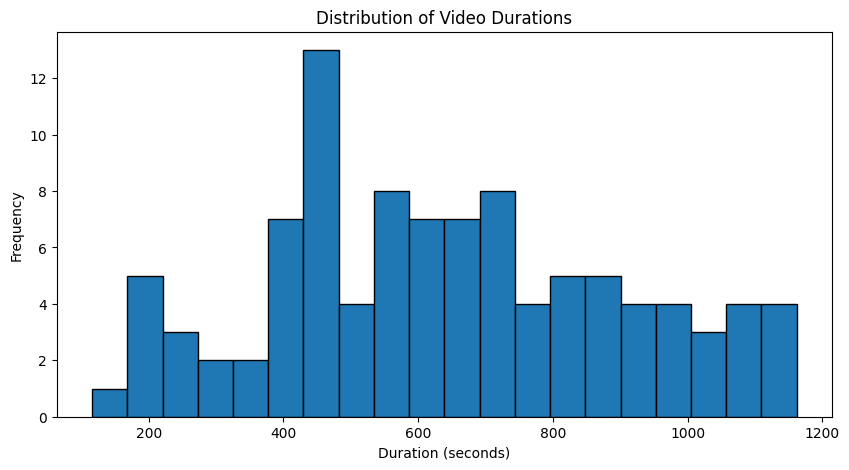

In [37]:
df_videos = pd.concat(all_dfs, ignore_index=True)
print(df_videos.columns)  # Debug: Check available columns
print(df_videos.head())
plot_duration_distribution(df_videos)

In [38]:
df = df_videos

In [39]:
print(df.head())

      Video ID                                          URL  Valid Duration  \
0  jOiOkFwBpNI  https://www.youtube.com/watch?v=jOiOkFwBpNI   True    189.0   
1  vBv5G5emgl0  https://www.youtube.com/watch?v=vBv5G5emgl0   True    433.0   
2  IkrXmYjWgIo  https://www.youtube.com/watch?v=IkrXmYjWgIo   True    988.0   
3  2rj9fXhUKnI  https://www.youtube.com/watch?v=2rj9fXhUKnI   True    771.0   
4  C0sdqnGCE2w  https://www.youtube.com/watch?v=C0sdqnGCE2w   True    955.0   

                                           Sentences                 Path  
0  [You won’t look amazing, Bad energy, No point,...      jOiOkFwBpNI.npy  
1  [Sheldon's Financial Situation - The Big Bang ...  vBv5G5emgl0.mp4.npy  
2  [Introduction, Unboxing, Unfolding, Front Whee...      IkrXmYjWgIo.npy  
3  [moon sparo - void, moon sparo - sink, dj quad...      2rj9fXhUKnI.npy  
4  [intro, allergy shots gone bad, I’m at the par...      C0sdqnGCE2w.npy  


In [40]:
# Display basic info
print("DataFrame Information:")
print(df.info())

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Video ID   100 non-null    object
 1   URL        100 non-null    object
 2   Valid      100 non-null    bool  
 3   Duration   100 non-null    object
 4   Sentences  100 non-null    object
 5   Path       100 non-null    object
dtypes: bool(1), object(5)
memory usage: 4.1+ KB
None


In [41]:
print("\nMissing Values")
print(df.isnull().sum()) 


Missing Values
Video ID     0
URL          0
Valid        0
Duration     0
Sentences    0
Path         0
dtype: int64


In [42]:
# Summary statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(df.describe())


Summary Statistics for Numerical Columns:
           Video ID                                          URL Valid  \
count           100                                          100   100   
unique          100                                          100     1   
top     jOiOkFwBpNI  https://www.youtube.com/watch?v=jOiOkFwBpNI  True   
freq              1                                            1   100   

       Duration                                          Sentences  \
count       100                                                100   
unique       96                                                100   
top       433.0  [You won’t look amazing, Bad energy, No point,...   
freq          2                                                  1   

                   Path  
count               100  
unique              100  
top     jOiOkFwBpNI.npy  
freq                  1  


In [43]:
import requests
import pandas as pd

def check_youtube_video_status(video_url):
    """
    Check if a YouTube video is Public, Private, Deleted, or Unavailable.
    
    Args:
        video_url (str): The full YouTube video URL.
    
    Returns:
        str: "Public", "Private", "Deleted", "Unavailable", or "Error".
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    try:
        response = requests.get(video_url, headers=headers, timeout=5)
        
        if response.status_code == 404 or response.status_code == 410:
            return "Deleted"
        
        page_content = response.text.lower()
        
        if "this video is private" in page_content:
            return "Private"
        elif "video unavailable" in page_content or "this video is no longer available" in page_content:
            return "Unavailable"
        elif response.status_code == 200:
            return "Public"
        
        return "Error"
    
    except requests.RequestException:
        return "Error"

# Update DataFrame with video status
df["Status"] = df["URL"].apply(check_youtube_video_status)

# Display updated DataFrame
print(df.head())

      Video ID                                          URL  Valid Duration  \
0  jOiOkFwBpNI  https://www.youtube.com/watch?v=jOiOkFwBpNI   True    189.0   
1  vBv5G5emgl0  https://www.youtube.com/watch?v=vBv5G5emgl0   True    433.0   
2  IkrXmYjWgIo  https://www.youtube.com/watch?v=IkrXmYjWgIo   True    988.0   
3  2rj9fXhUKnI  https://www.youtube.com/watch?v=2rj9fXhUKnI   True    771.0   
4  C0sdqnGCE2w  https://www.youtube.com/watch?v=C0sdqnGCE2w   True    955.0   

                                           Sentences                 Path  \
0  [You won’t look amazing, Bad energy, No point,...      jOiOkFwBpNI.npy   
1  [Sheldon's Financial Situation - The Big Bang ...  vBv5G5emgl0.mp4.npy   
2  [Introduction, Unboxing, Unfolding, Front Whee...      IkrXmYjWgIo.npy   
3  [moon sparo - void, moon sparo - sink, dj quad...      2rj9fXhUKnI.npy   
4  [intro, allergy shots gone bad, I’m at the par...      C0sdqnGCE2w.npy   

        Status  
0       Public  
1       Public  
2  Unavaila

In [44]:
import re
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
import nltk


In [49]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yashM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


In [ ]:
df["Sentences"] = df["Sentences"].apply(lambda x: ' '.join(eval(x)) if isinstance(x, str) else '')

In [47]:
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    words = word_tokenize(text)  # Tokenization
    words = [word for word in words if word not in stopwords.words('english')]  # Remove stopwords
    return " ".join(words)

In [48]:
df["Cleaned_Sentences"] = df["Sentences"].apply(clean_text)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\yashM/nltk_data'
    - 'c:\\Users\\yashM\\AppData\\Local\\Programs\\Python\\Python312\\nltk_data'
    - 'c:\\Users\\yashM\\AppData\\Local\\Programs\\Python\\Python312\\share\\nltk_data'
    - 'c:\\Users\\yashM\\AppData\\Local\\Programs\\Python\\Python312\\lib\\nltk_data'
    - 'C:\\Users\\yashM\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
all_words = " ".join(df["Cleaned_Sentences"]).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

KeyError: 'Cleaned_Sentences'

In [ ]:
bigrams = list(zip(all_words[:-1], all_words[1:]))
bigram_counts = Counter(bigrams).most_common(10)

In [ ]:
df["Sentiment"] = df["Sentences"].apply(lambda x: TextBlob(x).sentiment.polarity)

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
plt.barh([w[0] for w in common_words], [w[1] for w in common_words], color='skyblue')
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Common Words in Video Captions")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(all_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Video Captions")
plt.show()


In [ ]:
# Print results
print("Top 10 Common Words:", common_words[:10])
print("Top 10 Bigrams:", bigram_counts)
print("Sentiment Distribution:\n", df["Sentiment"].describe())